In [ ]:
"""This code processes a taxi dataset, encodes categorical features, visualizes correlations, and compares simple and multiple linear regression models to predict trip prices."""
# 1. Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


In [74]:
df = pd.read_csv("taxi_trip_pricing.csv")

In [75]:
df.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180


In [76]:
print(df.isnull().sum())

Trip_Distance_km         50
Time_of_Day              50
Day_of_Week              50
Passenger_Count          50
Traffic_Conditions       50
Weather                  50
Base_Fare                50
Per_Km_Rate              50
Per_Minute_Rate          50
Trip_Duration_Minutes    50
Trip_Price               49
dtype: int64


In [77]:
df = df.fillna(df.mean(numeric_only=True))

In [78]:
print(df.isnull().sum())

Trip_Distance_km          0
Time_of_Day              50
Day_of_Week              50
Passenger_Count           0
Traffic_Conditions       50
Weather                  50
Base_Fare                 0
Per_Km_Rate               0
Per_Minute_Rate           0
Trip_Duration_Minutes     0
Trip_Price                0
dtype: int64


In [79]:
df = df.dropna()

In [80]:
print(df.isnull().sum())

Trip_Distance_km         0
Time_of_Day              0
Day_of_Week              0
Passenger_Count          0
Traffic_Conditions       0
Weather                  0
Base_Fare                0
Per_Km_Rate              0
Per_Minute_Rate          0
Trip_Duration_Minutes    0
Trip_Price               0
dtype: int64


In [81]:
print("\nData types :")
print(df.dtypes)


Data types :
Trip_Distance_km         float64
Time_of_Day               object
Day_of_Week               object
Passenger_Count          float64
Traffic_Conditions        object
Weather                   object
Base_Fare                float64
Per_Km_Rate              float64
Per_Minute_Rate          float64
Trip_Duration_Minutes    float64
Trip_Price               float64
dtype: object


In [82]:
print(df['Time_of_Day'].nunique())
print(df['Time_of_Day'].unique())

4
['Morning' 'Afternoon' 'Evening' 'Night']


In [83]:
print(df['Day_of_Week'].nunique())
print(df['Day_of_Week'].unique())

2
['Weekday' 'Weekend']


In [84]:
print(df['Traffic_Conditions'].nunique())
print(df['Traffic_Conditions'].unique())

3
['Low' 'High' 'Medium']


In [85]:
print(df['Weather'].nunique())
print(df['Weather'].unique())

3
['Clear' 'Rain' 'Snow']


In [86]:
def encode_time_of_day(val):
    mapping = {'Morning': 0, 'Afternoon': 1, 'Evening': 2, 'Night': 3}
    return mapping[val]

def encode_day_of_week(val):
    mapping = {'Weekday': 0, 'Weekend': 1}
    return mapping[val]

def encode_traffic_conditions(val):
    mapping = {'Low': 0, 'Medium': 1, 'High': 2}
    return mapping[val]

def encode_weather(val):
    mapping = {'Clear': 0, 'Rain': 1, 'Snow': 2}
    return mapping[val]

In [87]:
df['Time_of_Day'] = df['Time_of_Day'].apply(encode_time_of_day)
df['Day_of_Week'] = df['Day_of_Week'].apply(encode_day_of_week)
df['Traffic_Conditions'] = df['Traffic_Conditions'].apply(encode_traffic_conditions)
df['Weather'] = df['Weather'].apply(encode_weather)

In [88]:
df.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.350000,0,0,3.0,0,0,3.560000,0.80,0.32,53.82,36.262400
1,47.590000,1,0,1.0,2,0,3.502989,0.62,0.43,40.57,56.874773
2,36.870000,2,1,1.0,2,0,2.700000,1.21,0.15,37.27,52.903200
4,27.070547,2,0,3.0,2,0,2.930000,0.63,0.32,22.64,15.618000
5,8.640000,1,1,2.0,1,0,2.550000,1.71,0.48,89.33,60.202800


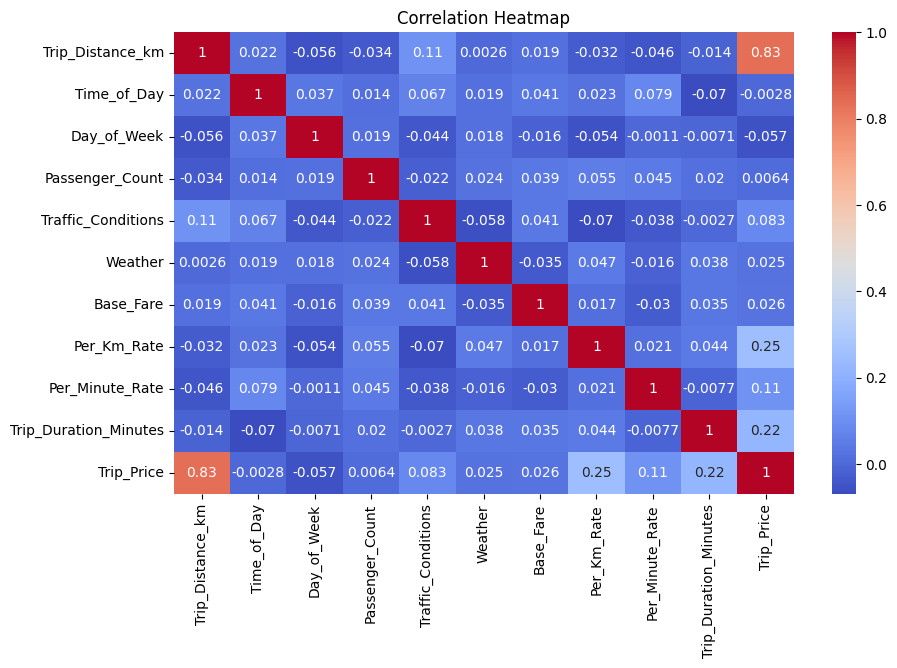

In [89]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [90]:
y = df['Trip_Price']

In [91]:
X = df.drop('Trip_Price', axis=1)

In [92]:
X_simple = df[['Trip_Distance_km']]

In [93]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_simple, y, test_size=0.2, random_state=42)

In [103]:
model_simple = LinearRegression()
model_simple.fit(X_train_s, y_train_s)

LinearRegression()

In [104]:
y_pred_s = model_simple.predict(X_test_s)

In [105]:
mse_simple = mean_squared_error(y_test_s, y_pred_s)
r2_simple = r2_score(y_test_s, y_pred_s)

In [106]:
print(f"Simple Linear Regression MSE : {mse_simple:.2f}")
print(f"Simple Linear Regression R²  : {r2_simple:.4f}")

Simple Linear Regression MSE : 431.68
Simple Linear Regression R²  : 0.7168


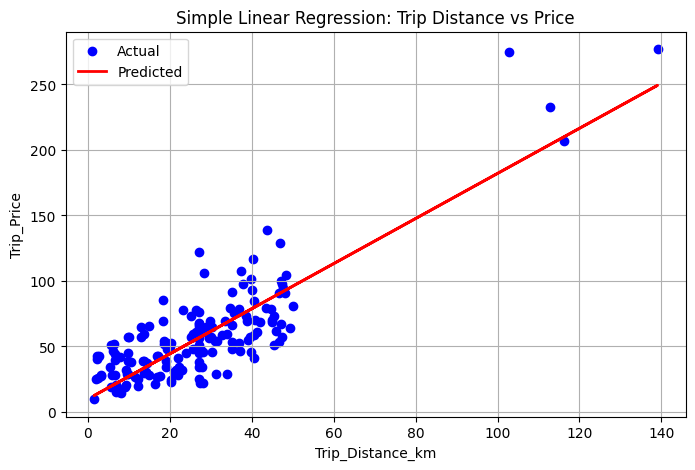

In [113]:
plt.figure(figsize=(8, 5))
plt.scatter(X_test_s, y_test_s, color='blue', label='Actual')
plt.plot(X_test_s, y_pred_s, color='red', linewidth=2, label='Predicted')
plt.xlabel("Trip_Distance_km")
plt.ylabel("Trip_Price")
plt.title("Simple Linear Regression: Trip Distance vs Price")
plt.legend()
plt.grid(True)
plt.show()

In [107]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [108]:
model_multiple = LinearRegression()
model_multiple.fit(X_train, y_train)

LinearRegression()

In [109]:
y_pred_m = model_multiple.predict(X_test)

In [110]:
mse_multiple = mean_squared_error(y_test, y_pred_m)
r2_multiple = r2_score(y_test, y_pred_m)

In [111]:
print(f"Multiple Linear Regression MSE: {mse_multiple:.2f}")
print(f"Multiple Linear Regression R² : {r2_multiple:.4f}")

Multiple Linear Regression MSE: 180.97
Multiple Linear Regression R² : 0.8813


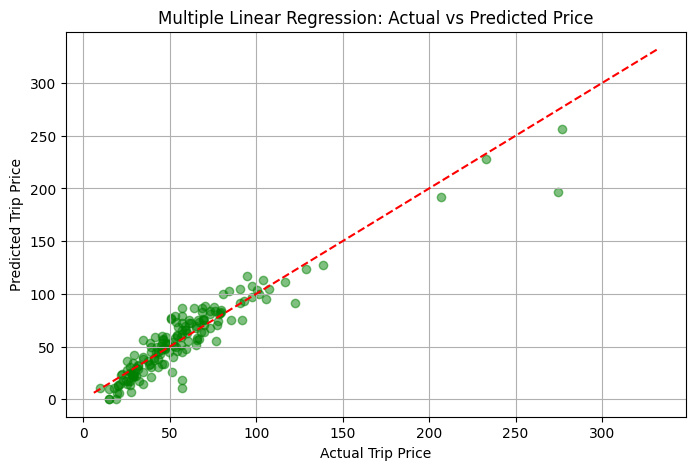

In [114]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_m, alpha=0.5, color='green')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual Trip Price")
plt.ylabel("Predicted Trip Price")
plt.title("Multiple Linear Regression: Actual vs Predicted Price")
plt.grid(True)
plt.show()

In [112]:
print("\n--- Model Comparison ---")
print(f"Simple Linear Regression MSE:   {mse_simple:.2f}")
print(f"Multiple Linear Regression MSE: {mse_multiple:.2f}")

if mse_multiple < mse_simple:
    print("Multiple regression is better")
else:
    print("Simple regression is better")


--- Model Comparison ---
Simple Linear Regression MSE:   431.68
Multiple Linear Regression MSE: 180.97
Multiple regression is better


In [ ]:
"""1–6: Import necessary libraries
import pandas as pd
→ For data manipulation.

import numpy as np
→ For numerical operations.

import matplotlib.pyplot as plt
→ For plotting.

import seaborn as sns
→ For advanced data visualizations.

from sklearn.linear_model import LinearRegression
→ To build linear regression models.

from sklearn.model_selection import train_test_split
→ To split data into training and testing sets.

from sklearn.metrics import mean_squared_error, r2_score
→ To evaluate model performance.

8–9: Load dataset
df = pd.read_csv("taxi_trip_pricing.csv")
→ Loads dataset into a DataFrame.

df.head()
→ Displays first five rows.

10–12: Handle missing values
print(df.isnull().sum())
→ Displays null counts.

df = df.fillna(df.mean(numeric_only=True))
→ Fills missing numeric values with column means.

print(df.isnull().sum())
→ Re-checks for missing values.

13–14: Drop any remaining missing values
df = df.dropna()

print(df.isnull().sum())
→ Ensures all nulls are removed.

15–16: Data types
print("\nData types :")

print(df.dtypes)
→ Displays data types for each column.

17–24: Explore categorical values
17–18: Time of Day (e.g., Morning, Evening)
19–20: Day of Week (Weekday/Weekend)
21–22: Traffic Conditions (Low/Medium/High)
23–24: Weather (Clear/Rain/Snow)
→ These help verify categories before encoding.

25–36: Encode categorical variables
25–28: encode_time_of_day(val)
29–32: encode_day_of_week(val)
33–36: encode_traffic_conditions(val)
37–40: encode_weather(val)
→ Maps categories to numeric values for modeling.

41–44: Apply encodings
df['Time_of_Day'] = df['Time_of_Day'].apply(encode_time_of_day)

df['Day_of_Week'] = df['Day_of_Week'].apply(encode_day_of_week)

df['Traffic_Conditions'] = df['Traffic_Conditions'].apply(encode_traffic_conditions)

df['Weather'] = df['Weather'].apply(encode_weather)
→ Converts text categories to numbers.

45: View updated DataFrame
df.head()

46–50: Visualize feature correlation
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10, 6))

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()
→ Helps identify strong relationships with price.

51–52: Separate features and target
y = df['Trip_Price']

X = df.drop('Trip_Price', axis=1)

53: Extract single feature for simple regression
X_simple = df[['Trip_Distance_km']]

54–55: Split data for simple regression
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_simple, y, test_size=0.2, random_state=42)

model_simple = LinearRegression()

56–58: Train and predict (simple regression)
model_simple.fit(X_train_s, y_train_s)

y_pred_s = model_simple.predict(X_test_s)

mse_simple = mean_squared_error(y_test_s, y_pred_s)

r2_simple = r2_score(y_test_s, y_pred_s)

60–61: Evaluate (simple regression)
print(f"Simple Linear Regression MSE : {mse_simple:.2f}")

print(f"Simple Linear Regression R² : {r2_simple:.4f}")

62–69: Plot simple regression results
plt.figure(figsize=(8, 5))

plt.scatter(X_test_s, y_test_s, color='blue', label='Actual')

plt.plot(X_test_s, y_pred_s, color='red', linewidth=2, label='Predicted')

plt.xlabel("Trip_Distance_km")

plt.ylabel("Trip_Price")

plt.title("Simple Linear Regression: Trip Distance vs Price")

plt.legend()

plt.grid(True)

plt.show()

71–72: Split data for multiple regression
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_multiple = LinearRegression()

73–75: Train and predict (multiple regression)
model_multiple.fit(X_train, y_train)

y_pred_m = model_multiple.predict(X_test)

mse_multiple = mean_squared_error(y_test, y_pred_m)

r2_multiple = r2_score(y_test, y_pred_m)

77–78: Evaluate (multiple regression)
print(f"Multiple Linear Regression MSE: {mse_multiple:.2f}")

print(f"Multiple Linear Regression R² : {r2_multiple:.4f}")

79–85: Plot multiple regression results
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred_m, alpha=0.5, color='green')

plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')

plt.xlabel("Actual Trip Price")

plt.ylabel("Predicted Trip Price")

plt.title("Multiple Linear Regression: Actual vs Predicted Price")

plt.grid(True)

plt.show()

87–92: Model comparison
print("\n--- Model Comparison ---")
88–89: Prints MSE for both models
90–92: Prints which model is better based on MSE

"""